# M2 — EDA & Statistics

Descriptive statistics, distributions, correlations and outlier review for the UCI Heart Disease dataset cleaned in `01_data_preparation.ipynb`.

## Load Cleaned Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("../data/heart_disease_clean.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


## Descriptive Statistics

In [2]:
# Descriptive statistics for numerical features
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [3]:
# Target distribution
df["target"].value_counts().sort_index()

target
0    164
1     55
2     36
3     35
4     13
Name: count, dtype: int64

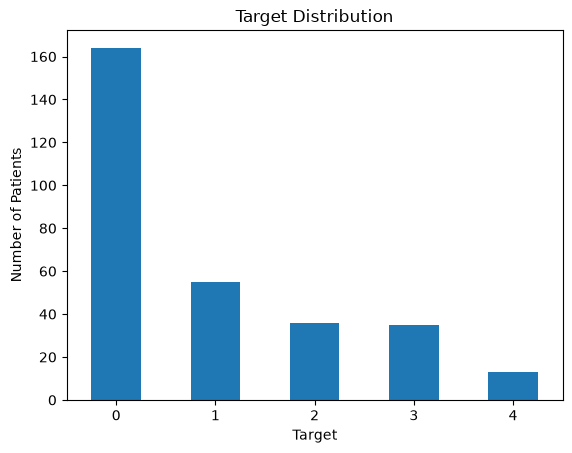

In [4]:
import matplotlib.pyplot as plt

df["target"].value_counts().sort_index().plot(kind="bar")

plt.title("Target Distribution")
plt.xlabel("Target")
plt.ylabel("Number of Patients")
plt.xticks(rotation=0)

import os
os.makedirs("../outputs", exist_ok=True)

plt.savefig("../outputs/target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## Distributions

In [5]:
numeric_columns = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

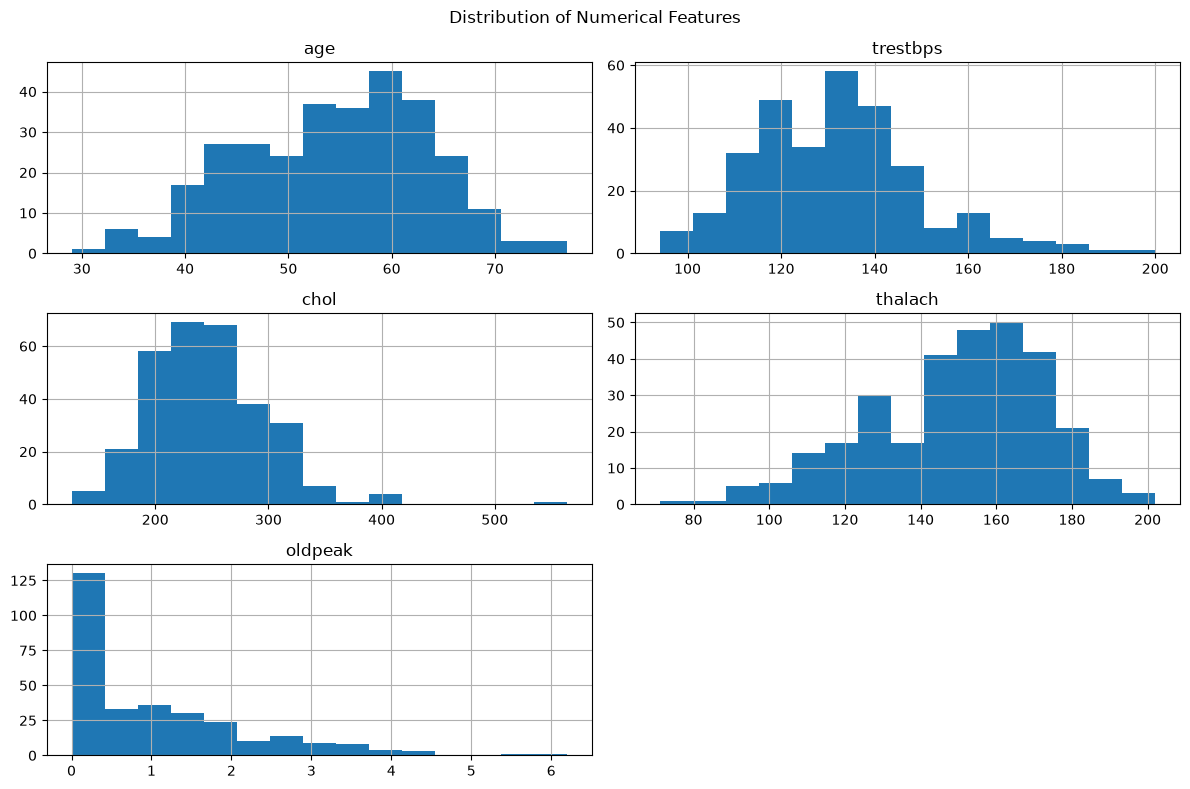

In [6]:
df[numeric_columns].hist(
    figsize=(12, 8),
    bins=15
)

plt.suptitle("Distribution of Numerical Features")
plt.tight_layout()
plt.show()

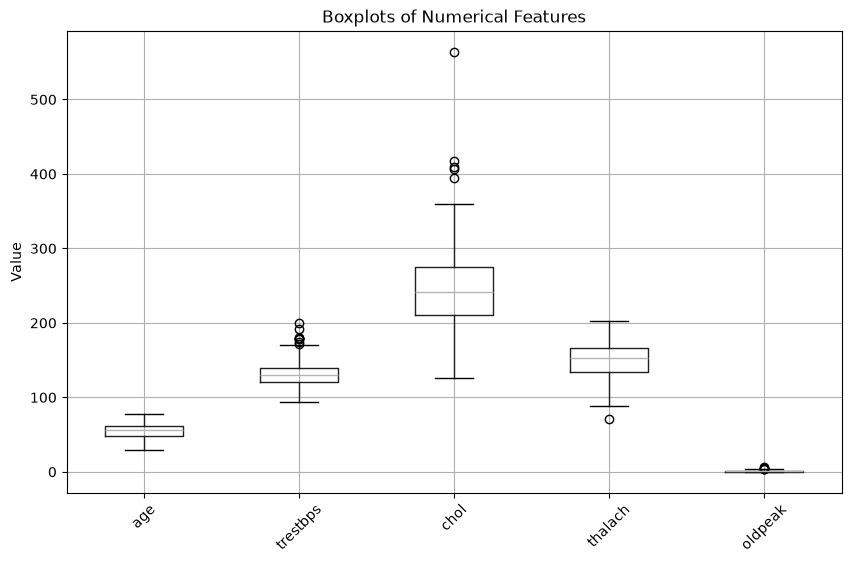

In [7]:
plt.figure(figsize=(10, 6))

df[numeric_columns].boxplot()

plt.title("Boxplots of Numerical Features")
plt.ylabel("Value")
plt.xticks(rotation=45)
plt.show()

## Outlier Analysis

Boxplots revealed potential outliers in `trestbps`, `chol`, `thalach`, and `oldpeak`.

These observations were not removed because they may represent valid medical measurements rather than data-entry errors. The values will be retained and handled during the preprocessing/modeling stage when appropriate.

## Correlation Analysis

In [8]:
# Correlation matrix
correlation_matrix = df.corr(numeric_only=True)

correlation_matrix

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,1.000000,-0.097542,0.104139,0.284946,0.208950,0.118530,0.148868,-0.393806,0.091661,0.203805,0.161770,0.362605,0.127389,0.222853
sex,-0.097542,1.000000,0.010084,-0.064456,-0.199915,0.047862,0.021647,-0.048663,0.146201,0.102173,0.037533,0.093185,0.380936,0.224469
cp,0.104139,0.010084,1.000000,-0.036077,0.072319,-0.039975,0.067505,-0.334422,0.384060,0.202277,0.152050,0.233214,0.265246,0.407075
trestbps,0.284946,-0.064456,-0.036077,1.000000,0.130120,0.175340,0.146560,-0.045351,0.064762,0.189171,0.117382,0.098773,0.133554,0.157754
chol,0.208950,-0.199915,0.072319,0.130120,1.000000,0.009841,0.171043,-0.003432,0.061310,0.046564,-0.004062,0.119000,0.014214,0.070909
fbs,0.118530,0.047862,-0.039975,0.175340,0.009841,1.000000,0.069564,-0.007854,0.025665,0.005747,0.059894,0.145478,0.071358,0.059186
restecg,0.148868,0.021647,0.067505,0.146560,0.171043,0.069564,1.000000,-0.083389,0.084867,0.114133,0.133946,0.128343,0.024531,0.183696
thalach,-0.393806,-0.048663,-0.334422,-0.045351,-0.003432,-0.007854,-0.083389,1.000000,-0.378103,-0.343085,-0.385601,-0.264246,-0.279631,-0.415040
exang,0.091661,0.146201,0.384060,0.064762,0.061310,0.025665,0.084867,-0.378103,1.000000,0.288223,0.257748,0.145570,0.329680,0.397057
oldpeak,0.203805,0.102173,0.202277,0.189171,0.046564,0.005747,0.114133,-0.343085,0.288223,1.000000,0.577537,0.295832,0.341004,0.504092


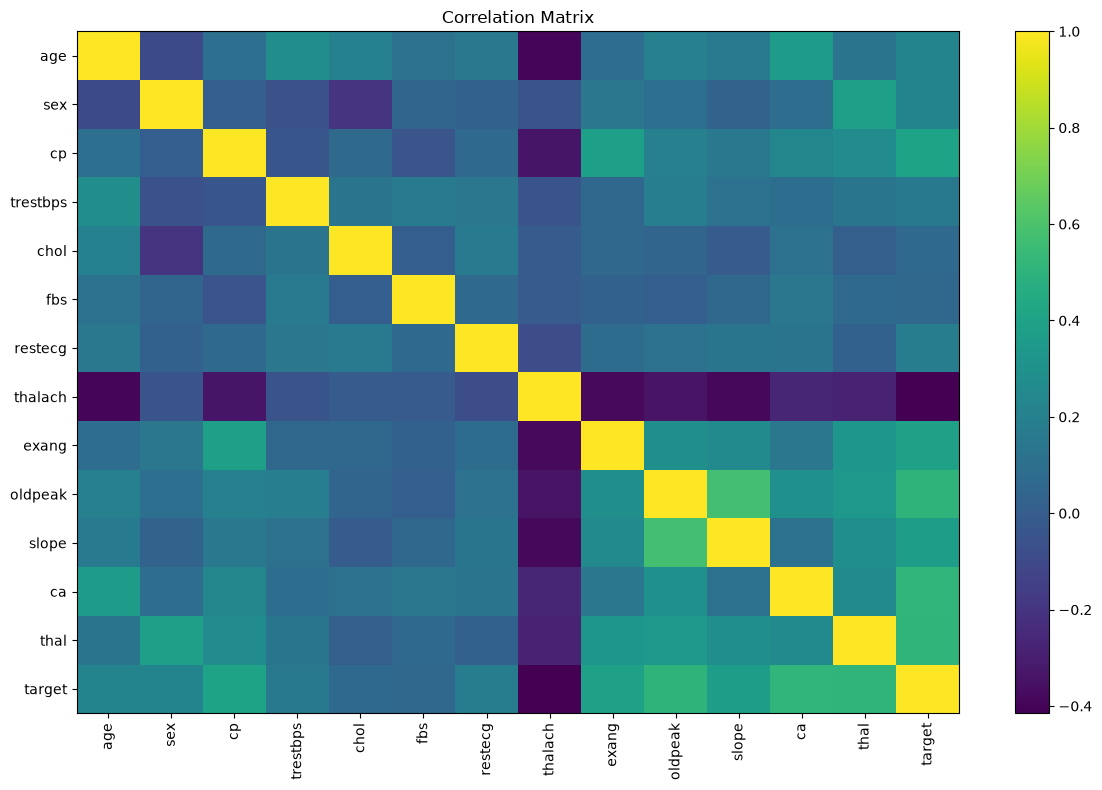

In [9]:
plt.figure(figsize=(12, 8))

plt.imshow(correlation_matrix, aspect="auto")

plt.colorbar()

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=90
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix")

plt.tight_layout()

import os
os.makedirs("../outputs", exist_ok=True)

plt.savefig("../outputs/correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

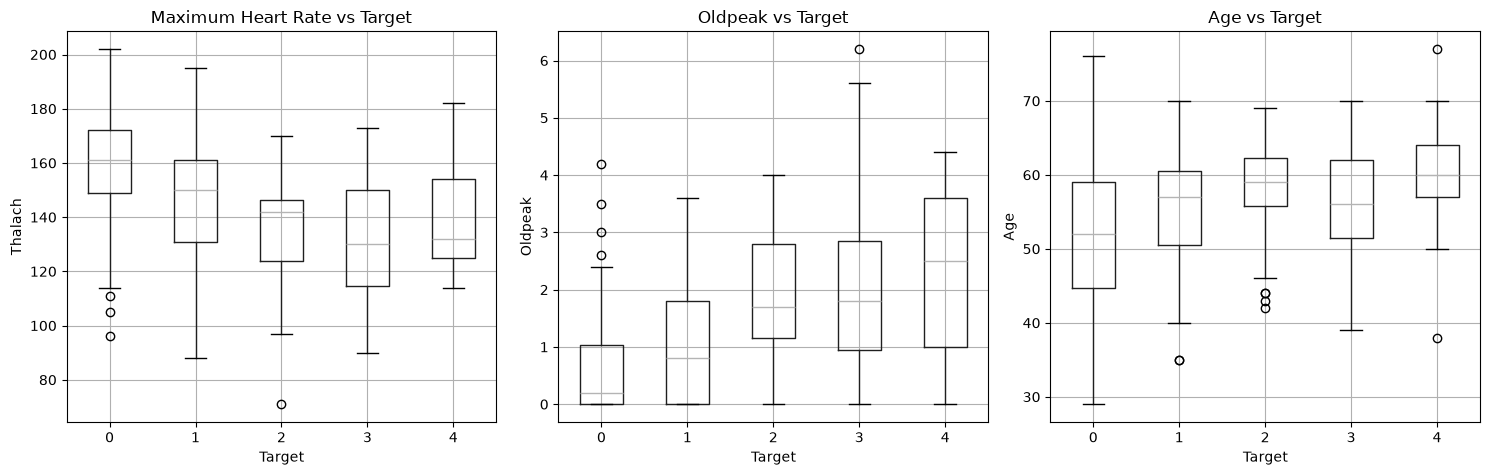

In [10]:
# Relationship between key numerical features and target

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

df.boxplot(column="thalach", by="target", ax=axes[0])
axes[0].set_title("Maximum Heart Rate vs Target")
axes[0].set_xlabel("Target")
axes[0].set_ylabel("Thalach")

df.boxplot(column="oldpeak", by="target", ax=axes[1])
axes[1].set_title("Oldpeak vs Target")
axes[1].set_xlabel("Target")
axes[1].set_ylabel("Oldpeak")

df.boxplot(column="age", by="target", ax=axes[2])
axes[2].set_title("Age vs Target")
axes[2].set_xlabel("Target")
axes[2].set_ylabel("Age")

plt.suptitle("")
plt.tight_layout()
plt.show()

## EDA Findings

- The dataset contains 303 patients with 13 features.
- The target variable is imbalanced, with class 0 being the largest group.
- Age is mainly distributed between approximately 40 and 70 years.
- Cholesterol and resting blood pressure contain several potential outliers.
- Oldpeak is strongly right-skewed, with most observations close to zero.
- `ca`, `thal`, and `oldpeak` show relatively strong positive correlations with the target.
- `thalach` shows a moderate negative correlation with the target.
- The relationship plots suggest that maximum heart rate and oldpeak differ across target classes.
- Potential outliers were retained because they may represent valid medical observations.
- Missing values remain in `ca` and `thal` and will be handled later within the preprocessing pipeline.